## **Data Preprocessing and Exploratory Data Analysis**

### **Import Libraries and Load Dataset**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option("display.max_columns", None)

BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

df = pd.read_csv(os.path.join(PROCESSED_DIR, "m5_merged_data.csv"))
df['date'] = pd.to_datetime(df['date'])

scope_info   = pd.read_csv(os.path.join(PROCESSED_DIR, "scope_selection.csv"))
top_store    = scope_info.loc[0, 'top_store']
top_category = scope_info.loc[0, 'top_category']

print("Store in scope:", top_store)
print("Category in scope:", top_category)


Store in scope: CA_3
Category in scope: FOODS


### **Filter to Selected Store and Category**

In [2]:
scope_df = df[
    (df['store_id'] == top_store) &
    (df['cat_id']   == top_category)
].copy()

print(f"Filtered to {top_store} / {top_category}: {scope_df.shape}")
display(scope_df.head())


Filtered to CA_3 / FOODS: (2748981, 28)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales_qty,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,is_event,event_count,is_cultural_event,is_national_event,is_religious_event,is_sport_event
7710,FOODS_1_001_CA_3_validation,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,d_1,1,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.00,0,0,0,0,0,0
7711,FOODS_1_002_CA_3_validation,FOODS_1_002,FOODS_1,FOODS,CA_3,CA,d_1,1,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,7.88,0,0,0,0,0,0
7712,FOODS_1_003_CA_3_validation,FOODS_1_003,FOODS_1,FOODS,CA_3,CA,d_1,1,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.88,0,0,0,0,0,0
7713,FOODS_1_004_CA_3_validation,FOODS_1_004,FOODS_1,FOODS,CA_3,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,0,0,0,0,0,0
7714,FOODS_1_005_CA_3_validation,FOODS_1_005,FOODS_1,FOODS,CA_3,CA,d_1,10,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.94,0,0,0,0,0,0


### **Aggregate to Store-Department Level**

Forecasting is performed at the store-department level, not at the individual SKU level. The data is therefore aggregated so that each row represents one department on one date.

Aggregation logic:
- `sales_qty` → sum of all item sales within the department on that date
- `sell_price` → average price across items in the department on that date
- All other columns (`weekday`, `month`, `year`, `snap_CA`, event flags) are date-level attributes and are retained directly as groupby keys


In [3]:
daily_df = (
    scope_df.groupby(
        ['date','dept_id','weekday','month','year','snap_CA',
         'is_event','event_count','is_cultural_event',
         'is_national_event','is_religious_event','is_sport_event'],
        as_index=False
    ).agg({'sales_qty':'sum','sell_price':'mean'})
    .sort_values(['dept_id','date'])
)

print("Department-level dataset shape:", daily_df.shape)
display(daily_df.head())


Department-level dataset shape: (5739, 14)


,date,dept_id,weekday,month,year,snap_CA,is_event,event_count,is_cultural_event,is_national_event,is_religious_event,is_sport_event,sales_qty,sell_price
0,2011-01-29,FOODS_1,Saturday,1,2011,0,0,0,0,0,0,0,341,2.976216
3,2011-01-30,FOODS_1,Sunday,1,2011,0,0,0,0,0,0,0,326,2.976216
6,2011-01-31,FOODS_1,Monday,1,2011,0,0,0,0,0,0,0,260,2.976216
9,2011-02-01,FOODS_1,Tuesday,2,2011,1,0,0,0,0,0,0,231,2.976216
12,2011-02-02,FOODS_1,Wednesday,2,2011,1,0,0,0,0,0,0,220,2.976216


### **Departments in Scope**

The three departments below become the individual forecasting units. Each will be modeled separately in the feature engineering and modeling steps.


In [4]:
dept_list = sorted(daily_df['dept_id'].drop_duplicates().tolist())
print("Departments selected for forecasting:")
for d in dept_list:
    print(" -", d)


Departments selected for forecasting:
 - FOODS_1
 - FOODS_2
 - FOODS_3


### **Compare Demand Trends Across Departments**

The chart below plots all three department series on the same time axis. This comparison helps identify whether the departments share similar patterns or whether each one needs to be treated independently.

As a demand planner, this is equivalent to reviewing a multi-SKU trend chart to decide whether to use a common forecast model or a separate model per item.


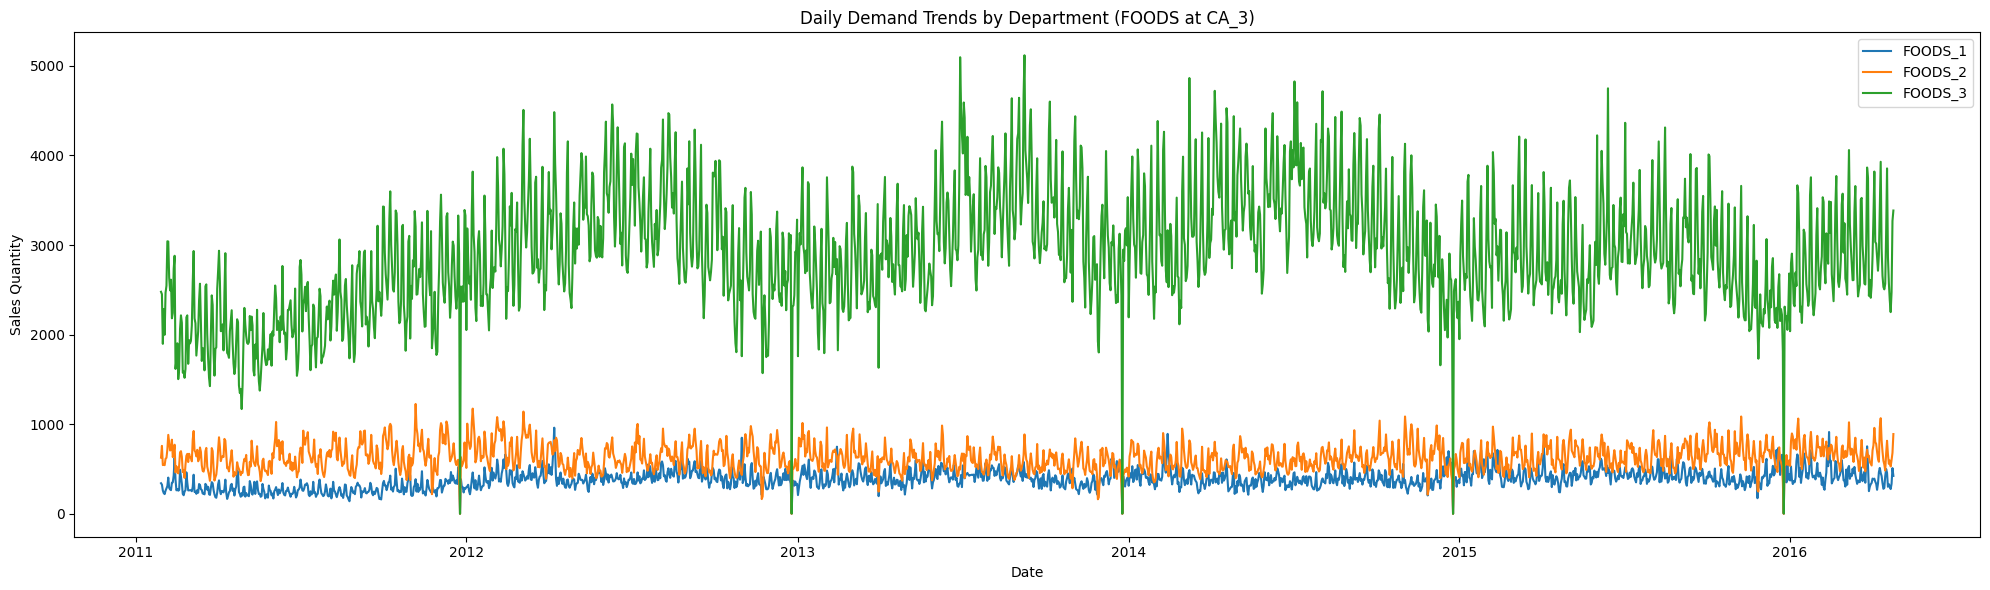

In [20]:
plt.figure(figsize=(20,6))
for dept in dept_list:
    temp = daily_df[(daily_df['dept_id'] == dept)]
    plt.plot(temp['date'], temp['sales_qty'], label=dept)

plt.title(f"Daily Demand Trends by Department ({top_category} at {top_store})")
plt.xlabel("Date"); plt.ylabel("Sales Quantity")
plt.legend(); plt.tight_layout(); plt.show()


**What the chart shows:**

The three departments differ noticeably in scale — FOODS_3 carries significantly more daily sales volume than FOODS_1 or FOODS_2. Each department also has its own level of day-to-day variability. These differences confirm that a separate model should be trained for each department rather than combining them into a single forecast.

### **Event Days vs Normal Days**

Food demand may be affected by special events. The table below compares average daily sales on event days versus non-event days and across different event counts.


In [23]:
event_sales = (
    daily_df.groupby(['is_event'])['sales_qty']
    .agg(['mean','median','std','count'])
    .reset_index()
)
event_count_summary = (
    daily_df.groupby('event_count')['sales_qty']
    .agg(['mean','median','std','count'])
    .reset_index()
)

print("Average sales by event presence:")
display(event_sales)
print("\nAverage sales by event count:")
display(event_count_summary)


Average sales by event presence:


,is_event,mean,median,std,count
0,0,1313.488156,624.0,1205.463514,5277
1,1,1265.179654,609.0,1219.522907,462



Average sales by event count:


,event_count,mean,median,std,count
0,0,1313.488156,624.0,1205.463514,5277
1,1,1258.386667,609.0,1212.252262,450
2,2,1519.916667,633.0,1507.133188,12


**What the event analysis shows - CA3 - FOODS Level:**

Non-event days make up the large majority of the dataset. Event days are relatively sparse, and most involve only a single event per day.

At this aggregated level, event days do not show a dramatic or consistent difference in average sales compared to non-event days. This does not mean events have no effect — the impact may be concentrated in specific event types or may only become visible when combined with other demand drivers such as SNAP benefits. The event indicator features are retained in the model because they may still contribute useful signal when analyzed together with other features.

### **STL Decomposition by Department**

STL (Seasonal and Trend decomposition using Loess) is applied to each department series using a weekly period of 7 days.

This separates the demand into three components:
- **Trend** — the gradual long-term direction of demand
- **Seasonal** — the repeating weekly pattern
- **Residual** — the remaining variation that neither trend nor seasonality explains

Understanding these components helps decide which types of models to use.

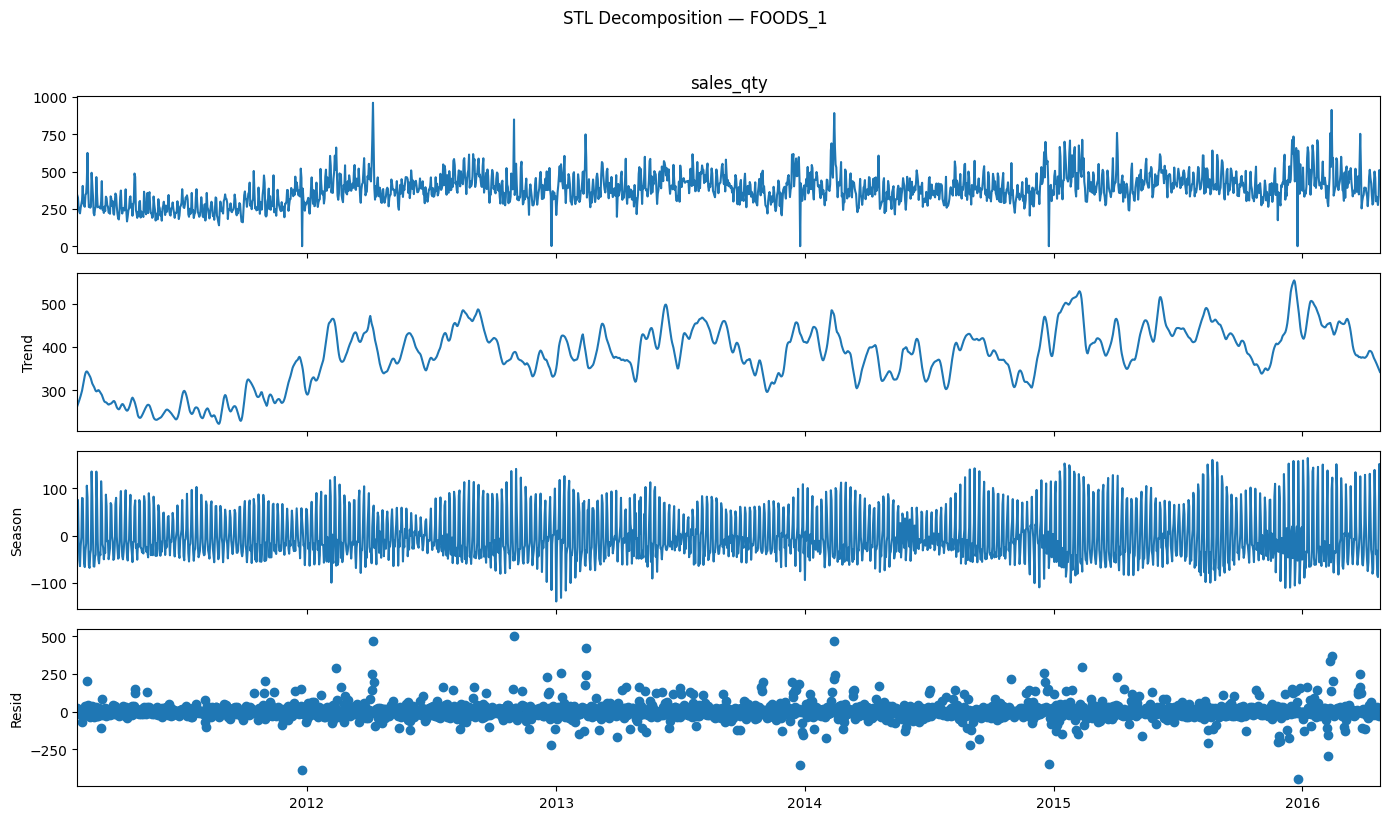

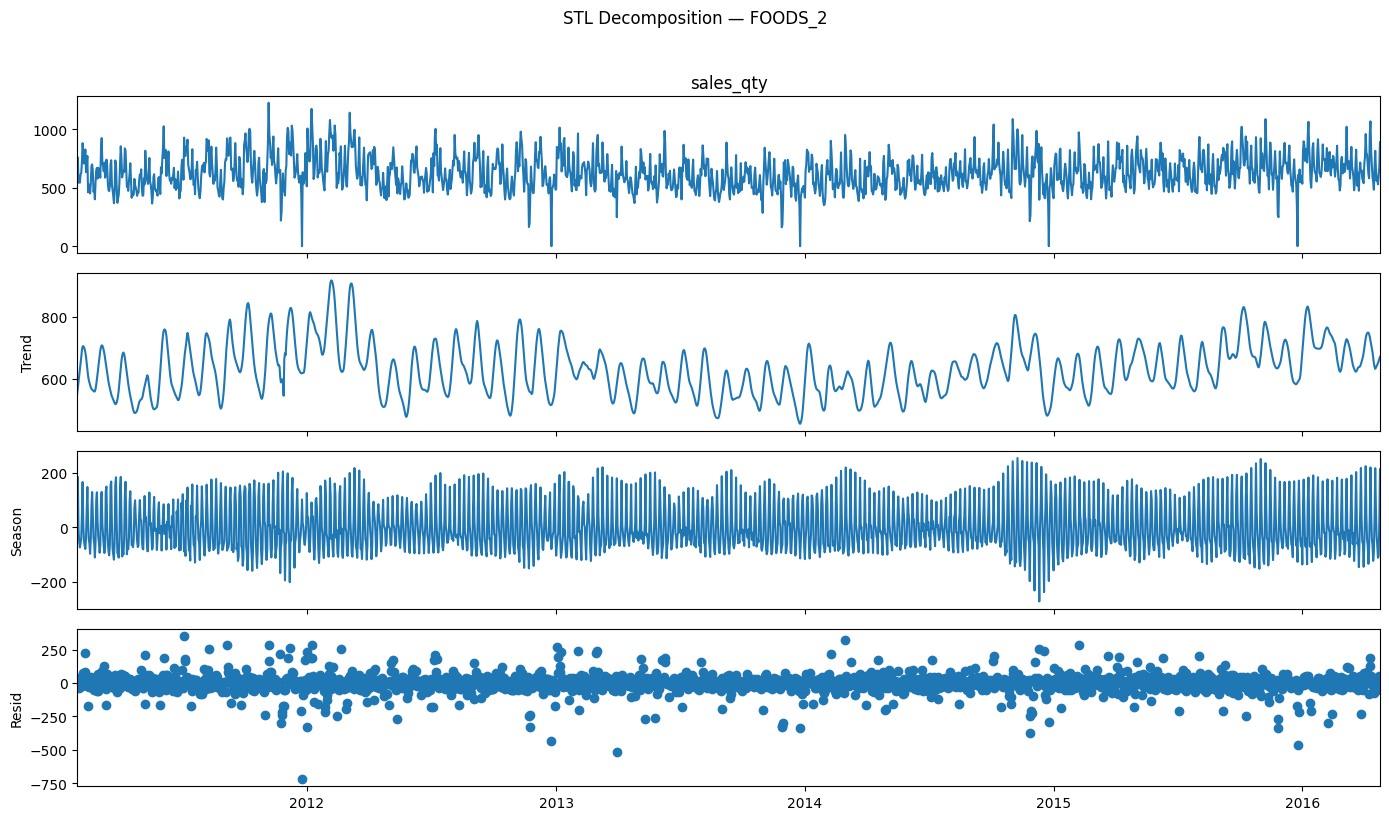

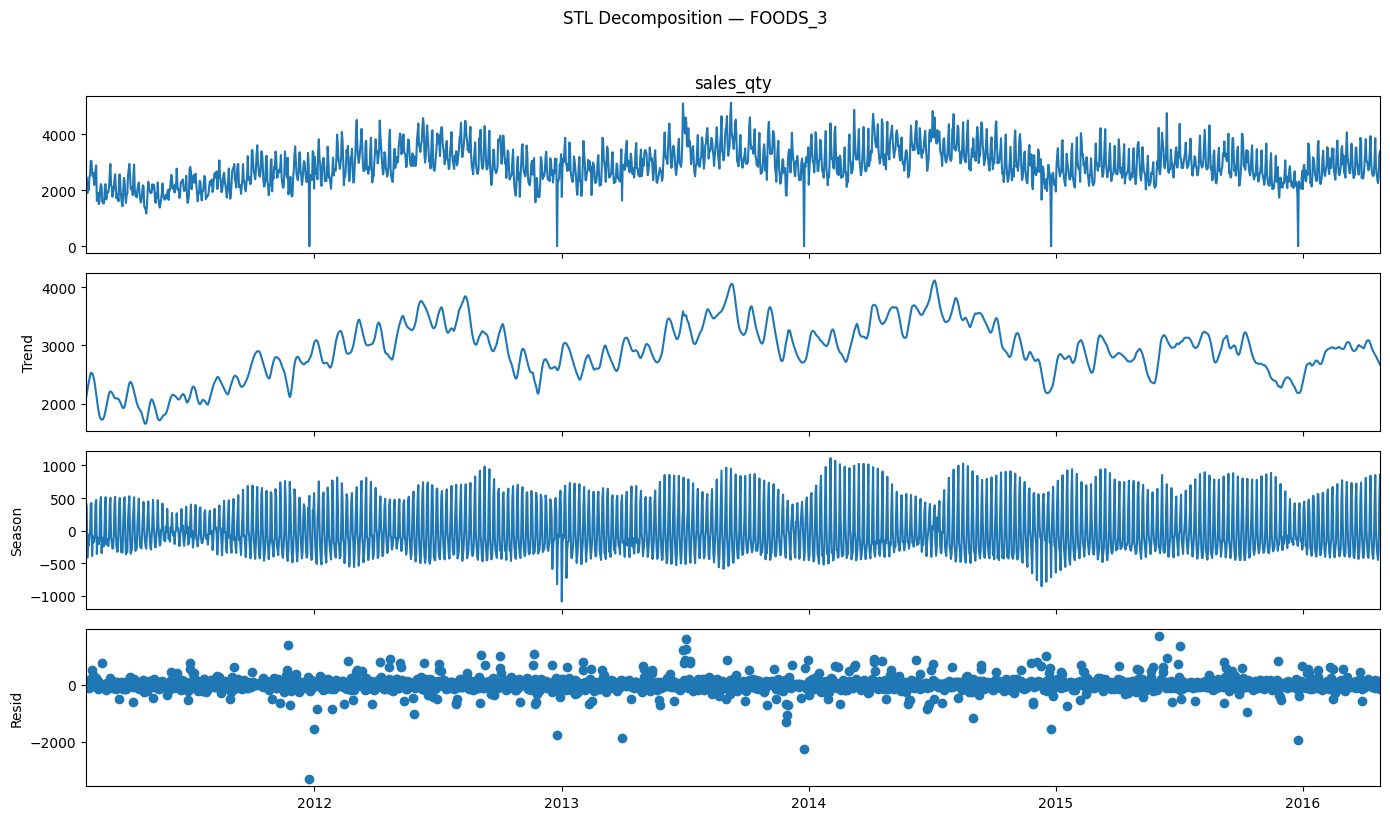


STL Summary:


,dept_id,avg_sales,trend_slope,trend_slope_pct,seasonal_strength
0,FOODS_1,385.19,0.0411,0.0001,0.4189
1,FOODS_2,628.63,0.0625,0.0001,0.5811
2,FOODS_3,2914.98,0.2968,0.0001,0.6424


In [28]:
trend_summary = []

for dept in dept_list:
    dept_series = (
        daily_df[(daily_df['dept_id'] == dept) & (daily_df['date'] >= pd.to_datetime('2011-01-01'))]
        .sort_values('date').set_index('date')['sales_qty']
        .asfreq('D').fillna(0)
    )
    stl    = STL(dept_series, period=7, robust=True)
    result = stl.fit()

    trend    = result.trend
    seasonal = result.seasonal
    resid    = result.resid

    trend_slope     = (trend.iloc[-1] - trend.iloc[0]) / len(trend)
    trend_slope_pct = trend_slope / dept_series.mean()

    trend_summary.append({
        'dept_id':          dept,
        'avg_sales':        round(dept_series.mean(), 2),
        'trend_slope':      round(trend_slope, 4),
        'trend_slope_pct':  round(trend_slope_pct, 4),
        'seasonal_strength':round(1 - (np.var(resid) / np.var(seasonal + resid)), 4)
    })

    fig = result.plot()
    fig.set_size_inches(14, 8)
    plt.suptitle(f"STL Decomposition — {dept}", y=1.02)
    plt.tight_layout(); plt.show()

trend_df = pd.DataFrame(trend_summary)
print("\nSTL Summary:")
display(trend_df)


**What the STL results show:**

- All three departments show a clear weekly seasonal component, confirming that day-of-week patterns are present and meaningful for forecasting. 
- The trend is relatively gradual — no sharp structural breaks.
- The seasonal strength metric (closer to 1 = stronger seasonality) shows whether the weekly cycle is a dominant driver of demand variation.
- The residual component confirms that some variation remains unexplained by trend and seasonality alone. This is where ML models with engineered lag and rolling features can add value by capturing demand drivers that simple statistical decomposition cannot.

### **ADF Stationarity Test**

The Augmented Dickey-Fuller test checks whether each department's demand series is stationary — meaning its statistical properties (mean, variance) do not change over time. Many traditional forecasting models require stationary input.

In [8]:
adf_results = []

for dept in dept_list:
    dept_series = (
        daily_df[daily_df['dept_id']==dept]
        .sort_values('date').set_index('date')['sales_qty']
        .asfreq('D').fillna(0)
    )
    result = adfuller(dept_series)
    adf_results.append({
        'dept_id':    dept,
        'ADF Stat':   round(result[0], 4),
        'p-value':    round(result[1], 4),
        'stationary': result[1] <= 0.05
    })

adf_df = pd.DataFrame(adf_results)
display(adf_df)


,dept_id,ADF Stat,p-value,stationary
0,FOODS_1,-3.3261,0.0138,True
1,FOODS_2,-4.0467,0.0012,True
2,FOODS_3,-2.5371,0.1067,False


**What the ADF results show:**

Departments with a p-value below 0.05 are considered stationary and can be used directly in ARIMA-type models. A department with p-value above 0.05 (such as FOODS_3 in the earlier run, where p ≈ 0.107) suggests non-stationarity — meaning the series may need one round of differencing before fitting ARIMA or SARIMA. This is why d=1 is included in the ARIMA order configurations used in the modeling step.


### **Autocorrelation Analysis — ACF and PACF**

**ACF (Autocorrelation Function)** shows how strongly past demand correlates with current demand at different lag distances. 

**PACF (Partial Autocorrelation Function)** shows the direct correlation at each lag after removing the influence of shorter lags.

These plots help confirm whether the lag features planned for the ML models are justified and what ARIMA order parameters are reasonable.


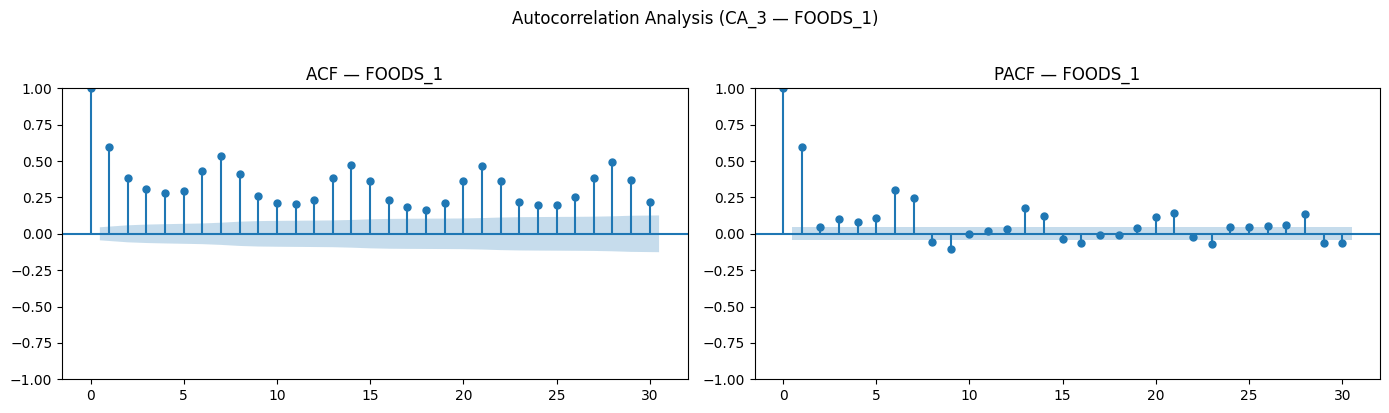

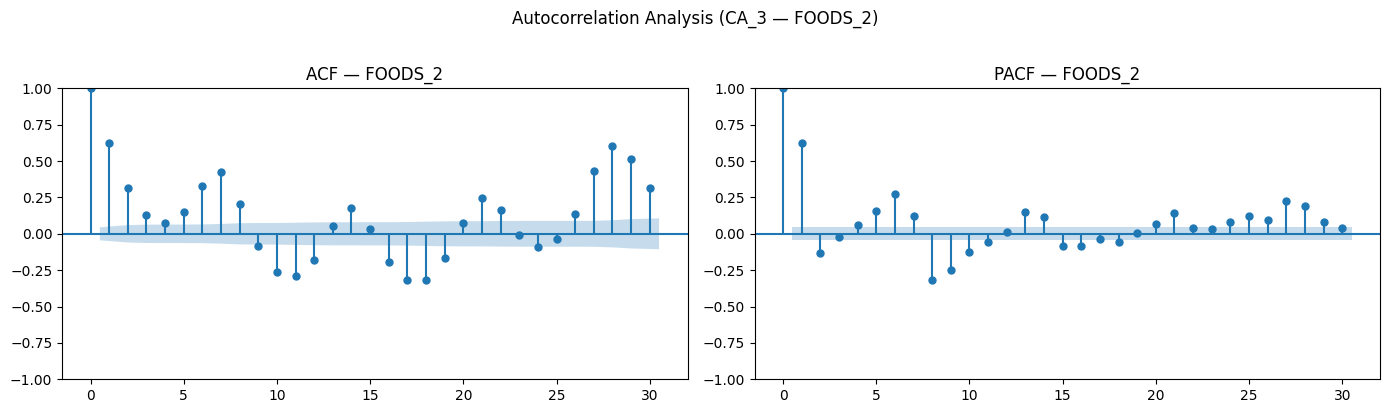

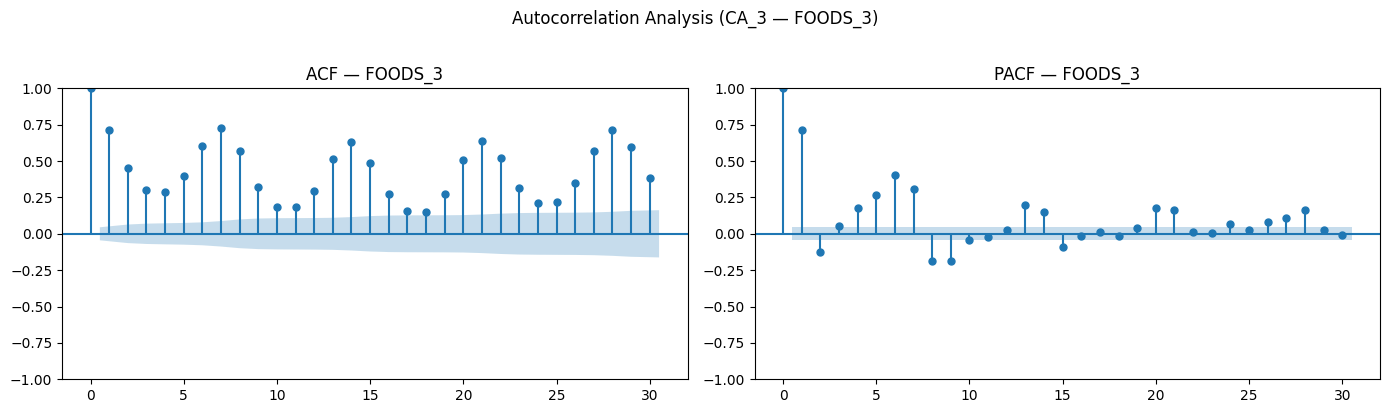

In [9]:
for dept in dept_list:
    dept_series = (
        daily_df[daily_df['dept_id']==dept]
        .sort_values('date').set_index('date')['sales_qty']
        .asfreq('D').fillna(0)
    )
    fig, axes = plt.subplots(1, 2, figsize=(14,4))
    plot_acf( dept_series, lags=30, ax=axes[0])
    axes[0].set_title(f"ACF — {dept}")
    plot_pacf(dept_series, lags=30, ax=axes[1])
    axes[1].set_title(f"PACF — {dept}")
    plt.suptitle(f"Autocorrelation Analysis ({top_store} — {dept})", y=1.02)
    plt.tight_layout(); plt.show()


**What the ACF and PACF show:**

Strong autocorrelation at lag 1 confirms that yesterday's demand is a useful predictor of today's demand. Significant spikes at weekly multiples (lag 7, 14, 21) confirm the weekly seasonal cycle. These patterns directly justify the need for lag features to be created in the feature engineering step and the use of a seasonal period of 7 in SARIMA and Exponential Smoothing models.

### **Data Quality Check — Missing Values**

In [10]:
print("Missing value check before feature engineering:")
display(daily_df.isna().sum())

# Fill any missing sell_price with the department median
daily_df['sell_price'] = (
    daily_df.groupby('dept_id')['sell_price']
    .transform(lambda x: x.fillna(x.median()))
)

print("\nMissing values after sell_price fill:")
display(daily_df.isna().sum())


Missing value check before feature engineering:


date                  0
dept_id               0
weekday               0
month                 0
year                  0
snap_CA               0
is_event              0
event_count           0
is_cultural_event     0
is_national_event     0
is_religious_event    0
is_sport_event        0
sales_qty             0
sell_price            0
dtype: int64


Missing values after sell_price fill:


date                  0
dept_id               0
weekday               0
month                 0
year                  0
snap_CA               0
is_event              0
event_count           0
is_cultural_event     0
is_national_event     0
is_religious_event    0
is_sport_event        0
sales_qty             0
sell_price            0
dtype: int64

The missing value check is run before passing the dataset to the feature engineering step. If any gaps appear in `sell_price`, they are filled using the department-level median price. This is a conservative approach that avoids introducing misleading price signals while still allowing the dataset to remain complete.


### **Save Dataset for Feature Engineering**

In [ ]:
daily_df.to_csv(os.path.join(PROCESSED_DIR, "store_dept_daily_sales.csv"), index=False)
print("Saved: store_dept_daily_sales.csv")
print("Shape:", daily_df.shape)


Saved: store_dept_daily_sales.csv
Shape: (5739, 14)
